## Use Naive Bayes to predict whether income exceeds $50K/yr based on census data. Also known as the "Census Income" dataset.


# Import the library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Load the dataset

In [2]:
df = pd.read_csv('adult.csv')

In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.shape

(32561, 15)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


### Data Preprocessing

In [6]:
df['income'].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [7]:
df = df.drop(columns=['fnlwgt'])

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   education       32561 non-null  object
 3   education.num   32561 non-null  int64 
 4   marital.status  32561 non-null  object
 5   occupation      32561 non-null  object
 6   relationship    32561 non-null  object
 7   race            32561 non-null  object
 8   sex             32561 non-null  object
 9   capital.gain    32561 non-null  int64 
 10  capital.loss    32561 non-null  int64 
 11  hours.per.week  32561 non-null  int64 
 12  native.country  32561 non-null  object
 13  income          32561 non-null  object
dtypes: int64(5), object(9)
memory usage: 3.5+ MB


#### Handling missing values

In [9]:
df.isnull().sum()

age               0
workclass         0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

## Drop Duplicates

In [10]:
df[df.duplicated()]

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
88,55,Self-emp-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,2415,50,United-States,>50K
401,34,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1977,45,United-States,>50K
513,43,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1977,50,United-States,>50K
829,41,Self-emp-inc,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,1887,55,United-States,>50K
875,55,Private,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1887,40,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32508,47,Private,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,<=50K
32517,20,Private,HS-grad,9,Never-married,Machine-op-inspct,Own-child,White,Male,0,0,40,United-States,<=50K
32530,22,Private,Some-college,10,Never-married,Adm-clerical,Own-child,White,Male,0,0,40,United-States,<=50K
32558,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K


#### Remove Duplicates

In [11]:
df.duplicated().sum()

3465

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df = df.reset_index()

In [14]:
df.isnull().sum()

index             0
age               0
workclass         0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [15]:
df = df.drop(columns=['index'])

In [16]:
num_columns = [col for col in df.columns if df[col].dtype != object]
cat_columns = [col for col in df.columns if df[col].dtype == object]

#### Since in the categorical columns have '?' we will replace with mode values

In [17]:
for i in cat_columns:
    mode = df[i].mode()
    z=mode.values[0]
    #print(z)
    df.replace({i:{'?':z}},inplace=True)

In [18]:
df.head()

,age,workclass,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,Private,HS-grad,9,Widowed,Prof-specialty,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Private,Some-college,10,Widowed,Prof-specialty,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Dealing Outliers

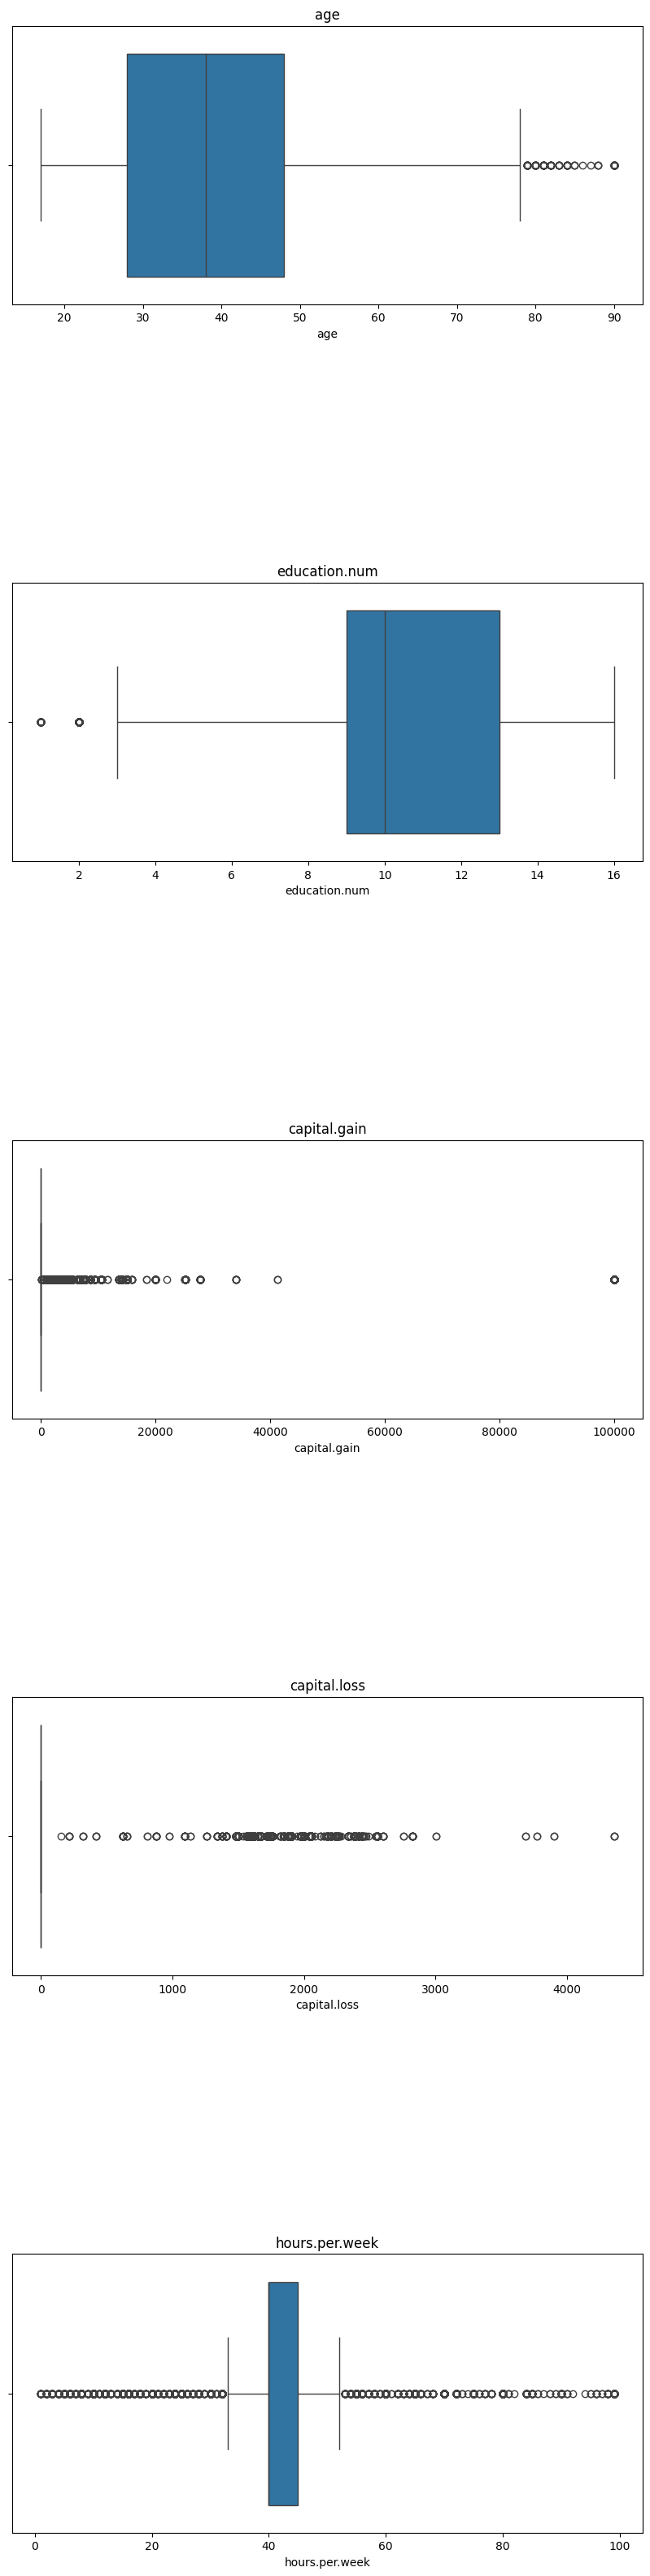

In [19]:
fig, axes = plt.subplots(nrows=len(num_columns), ncols=1, figsize=(10, 40))

for i, col in enumerate(num_columns):
    sns.boxplot(data=df, x=col, ax=axes[i]) 
    axes[i].set_title(col)
    plt.subplots_adjust(hspace=1) 

#### Removing Outlier with Max and min values

In [20]:
#num_outliers.shape

In [21]:
for i in num_columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    valid = df[(df[i] > lower_bound) & (df[i] < upper_bound)]
    #print(outliers)
    #df.loc[df[i]>upper_bound,i]=upper_bound
    #df.loc[df[i]<lower_bound,i]=lower_bound

In [22]:
for i in num_columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    valid = df[(df[i] < lower_bound) | (df[i] > upper_bound)]
    #print(outliers)
    valid.loc[df[i]>upper_bound,i]=upper_bound
    valid.loc[df[i]<lower_bound,i]=lower_bound

C:\Users\dhana\AppData\Local\Temp\ipykernel_19584\56590923.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '52.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  valid.loc[df[i]>upper_bound,i]=upper_bound


In [23]:
valid.shape

(8476, 14)

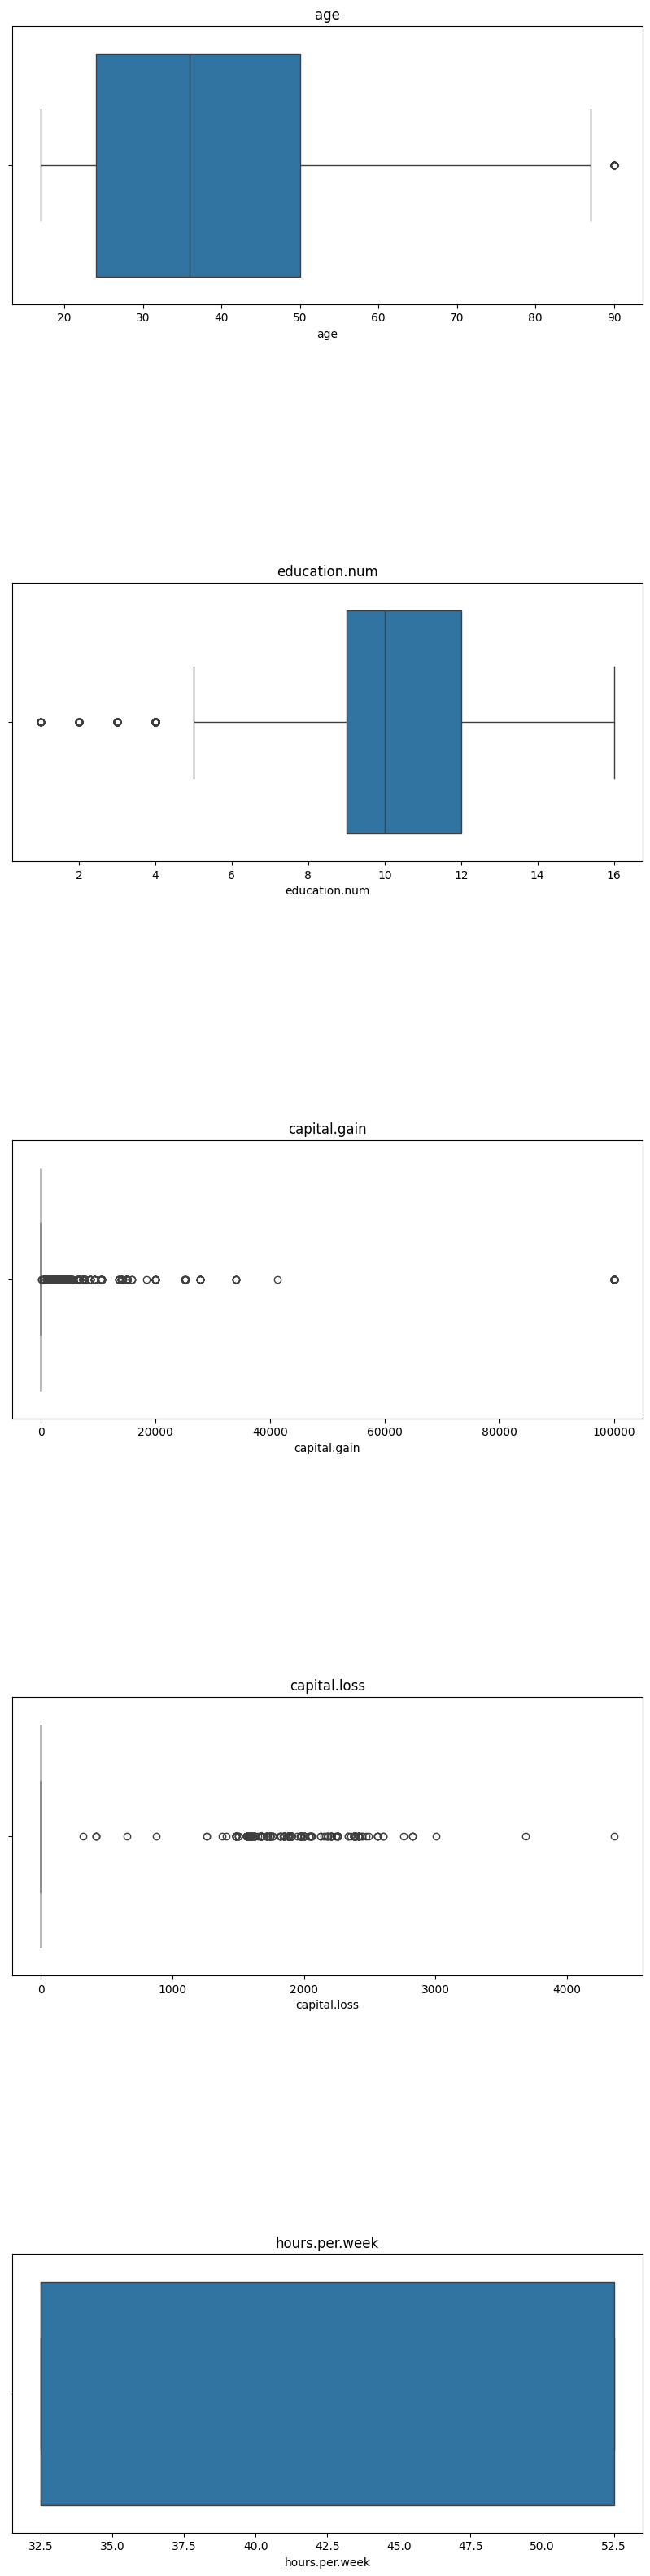

In [24]:
fig, axes = plt.subplots(nrows=len(num_columns), ncols=1, figsize=(10, 40))

for i, col in enumerate(num_columns):
    sns.boxplot(data=valid, x=col, ax=axes[i]) 
    axes[i].set_title(col)
    plt.subplots_adjust(hspace=1) 

In [25]:
df['capital.gain'].unique()

array([    0, 99999, 41310, 34095, 27828, 25236, 25124, 22040, 20051,
       18481, 15831, 15024, 15020, 14344, 14084, 13550, 11678, 10605,
       10566, 10520,  9562,  9386,  8614,  7978,  7896,  7688,  7443,
        7430,  7298,  6849,  6767,  6723,  6514,  6497,  6418,  6360,
        6097,  5721,  5556,  5455,  5178,  5060,  5013,  4934,  4931,
        4865,  4787,  4687,  4650,  4508,  4416,  4386,  4101,  4064,
        3942,  3908,  3887,  3818,  3781,  3674,  3471,  3464,  3456,
        3432,  3418,  3411,  3325,  3273,  3137,  3103,  2993,  2977,
        2964,  2961,  2936,  2907,  2885,  2829,  2653,  2635,  2597,
        2580,  2538,  2463,  2414,  2407,  2387,  2354,  2346,  2329,
        2290,  2228,  2202,  2176,  2174,  2105,  2062,  2050,  2036,
        2009,  1848,  1831,  1797,  1639,  1506,  1471,  1455,  1424,
        1409,  1173,  1151,  1111,  1086,  1055,   991,   914,   594,
         401,   114], dtype=int64)

In [26]:
df['capital.loss'].unique()

array([4356, 3900, 3770, 3683, 3004, 2824, 2754, 2603, 2559, 2547, 2489,
       2472, 2467, 2457, 2444, 2415, 2392, 2377, 2352, 2339, 2282, 2267,
       2258, 2246, 2238, 2231, 2206, 2205, 2201, 2179, 2174, 2163, 2149,
       2129, 2080, 2057, 2051, 2042, 2002, 2001, 1980, 1977, 1974, 1944,
       1902, 1887, 1876, 1848, 1844, 1825, 1816, 1762, 1755, 1741, 1740,
       1735, 1726, 1721, 1719, 1672, 1669, 1668, 1651, 1648, 1628, 1617,
       1602, 1594, 1590, 1579, 1573, 1564, 1539, 1504, 1485, 1411, 1408,
       1380, 1340, 1258, 1138, 1092,  974,  880,  810,  653,  625,  419,
        323,  213,  155,    0], dtype=int64)

# heatmap

In [27]:
num_columns = [col for col in valid.columns if valid[col].dtype != object]

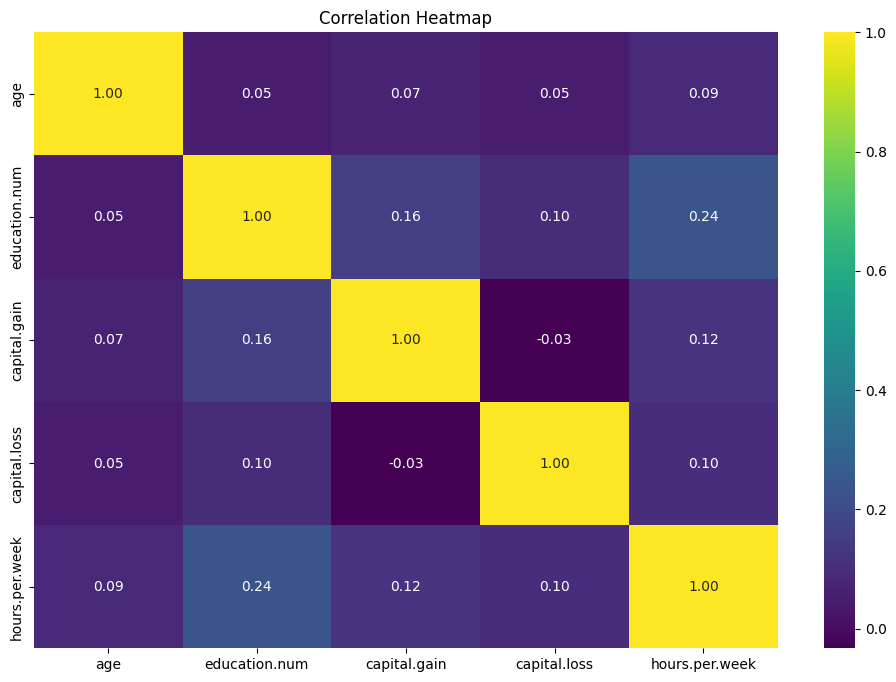

In [28]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(valid[num_columns].corr(), annot=True, cmap='viridis', fmt=".2f", cbar=True)
plt.title("Correlation Heatmap")
plt.show()

### Encoding

In [29]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [30]:
for col in cat_columns:
    valid[col] = encoder.fit_transform(valid[col])

C:\Users\dhana\AppData\Local\Temp\ipykernel_19584\3833911117.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid[col] = encoder.fit_transform(valid[col])
C:\Users\dhana\AppData\Local\Temp\ipykernel_19584\3833911117.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid[col] = encoder.fit_transform(valid[col])
C:\Users\dhana\AppData\Local\Temp\ipykernel_19584\3833911117.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

In [31]:
valid.duplicated().sum()

948

In [32]:
valid = valid.drop_duplicates()

### Classify X and y

In [33]:
y = valid['income']
X = valid.drop('income',axis=1)

### Scaling

In [34]:
valid= valid.reset_index()

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [36]:
num_columns = [col for col in X.columns if X[col].dtype != object]

In [37]:
X[num_columns] = scaler.fit_transform(X[num_columns])

### Drop irrelevent column

In [38]:
valid = valid.drop(columns=['race','sex','index'])

In [39]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# model

In [40]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

In [41]:
nb.fit(X_train,y_train)

GaussianNB()

In [42]:
y_pred = nb.predict(X_test)

In [43]:
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [44]:
y_test_encode = encoder.fit_transform(y_test)

In [45]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_pred,y_test)
print(f"accuracy : {accuracy *100:.2f}%")

accuracy : 83.47%


In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

In [47]:
print(f"precision : {precision *100:.2f}%")
print(f"f1_score : {f1 *100:.2f}%")

precision : 73.68%
f1_score : 55.30%
